In [1]:
import pandas as pd
import numpy as np

### Q-1)Below questions are based on this data(ncr_ride_bookings):-

In [4]:
rides = pd.read_csv("ncr_ride_bookings.csv", parse_dates = ["Date"])

In [5]:
rides.sample(2)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
9828,2024-03-08,09:14:10,"""CNR3617382""",Completed,"""CID6871626""",Go Mini,Shastri Park,Ramesh Nagar,4.9,27.0,...,NaN,NaN,NaN,NaN,NaN,94.0,39.64,4.7,4.9,Credit Card
28885,2024-04-30,17:58:32,"""CNR2523139""",Completed,"""CID9853121""",Auto,IIT Delhi,Badshahpur,5.1,36.7,...,NaN,NaN,NaN,NaN,NaN,217.0,43.61,3.9,4.3,UPI


#### 1)Convert Date and Time to datetime


In [6]:
rides["Date"].dtype # we had converted the date col to date col to datetime dtype at time of reading csv file

dtype('<M8[ns]')

In [7]:
rides["Time"] = pd.to_datetime(rides["Time"], errors = "coerce", format = "%H:%M:%S") 
## pandas add dummy date to time 1900-01-01 hh:mm:ss
# if we don't want this dummy date then do this:
# pd.to_datetime(rides["Time"], errors = "coerce", format = "%H:%M:%S").dt.time .
# However, this will be python datetime obj and will be of "object type".

In [8]:
rides["Time"].dtype

dtype('<M8[ns]')

In [9]:
rides.sample()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
128563,2024-06-19,1900-01-01 20:37:07,"""CNR9249724""",No Driver Found,"""CID1134862""",Bike,Laxmi Nagar,Rohini East,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2)Combine Date and Time into a single datetime column
##### method 1:

Since our "Date" and "Time" are both datetime, we can’t directly add them.
But if we convert each to string in the right format using .dt.strftime(),
then concatenate, then parse back → we get a clean datetime column:

##### method 2:
we could also combine these two cols durind reading the file time only using parde_date = [" "] and get datetime type col

##### some situation:

if: 

"Date" is datetime64[ns]

"Time" (after pd.to_datetime(rides["Time"], errors = "coerce", format = "%H:%M:%S").dt.time .) is Python datetime.time objects (object dtype)

Pandas can’t directly add those two.

solution: 

rides["Date Time"] = pd.to_datetime( rides["Date"].astype(str) + " " + rides["Time"].astype(str),errors="coerce")




In [10]:
#method 1:

rides["Date Time"] = pd.to_datetime(rides["Date"].dt.strftime("%Y-%m-%d")+" "+ rides["Time"].dt.strftime("%H-%M-%S"), format = "%Y-%m-%d %H-%M-%S",errors = "coerce")

In [11]:
rides["Date Time"].dtype

dtype('<M8[ns]')

In [12]:
rides.sample(3)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Date Time
25937,2024-11-24,1900-01-01 14:41:11,"""CNR9862158""",Cancelled by Driver,"""CID2672646""",Go Mini,Maidan Garhi,Shastri Nagar,4.6,NaN,...,1.0,The customer was coughing/sick,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-24 14:41:11
58276,2024-04-09,1900-01-01 10:37:57,"""CNR7240771""",Completed,"""CID8036657""",Premier Sedan,Chandni Chowk,Bahadurgarh,4.5,33.9,...,NaN,NaN,NaN,NaN,153.0,18.36,4.1,3.9,Cash,2024-04-09 10:37:57
10222,2024-02-08,1900-01-01 16:37:07,"""CNR4070243""",Cancelled by Customer,"""CID9448869""",Auto,Rajiv Nagar,Faridabad Sector 15,6.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-08 16:37:07


In [13]:
#method 2:
#will be deprecated in future . so use above method
rides2 = pd.read_csv("ncr_ride_bookings.csv", parse_dates = {"DateTime" : ["Date","Time"]})

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\1027789386.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  rides2 = pd.read_csv("ncr_ride_bookings.csv", parse_dates = {"DateTime" : ["Date","Time"]})


In [14]:
rides2

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11 19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24 15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18 10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05 07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


#### 3)Extract temporal features

In [15]:
rides["Date Time"].dt.year

0         2024
1         2024
2         2024
3         2024
4         2024
          ... 
149995    2024
149996    2024
149997    2024
149998    2024
149999    2024
Name: Date Time, Length: 150000, dtype: int32

In [16]:
rides["Date Time"].dt.month

0          3
1         11
2          8
3         10
4          9
          ..
149995    11
149996    11
149997     9
149998    10
149999     3
Name: Date Time, Length: 150000, dtype: int32

In [17]:
rides["Date Time"].dt.day

0         23
1         29
2         23
3         21
4         16
          ..
149995    11
149996    24
149997    18
149998     5
149999    10
Name: Date Time, Length: 150000, dtype: int32

In [18]:
rides["Date Time"].dt.day_name()

0          Saturday
1            Friday
2            Friday
3            Monday
4            Monday
            ...    
149995       Monday
149996       Sunday
149997    Wednesday
149998     Saturday
149999       Sunday
Name: Date Time, Length: 150000, dtype: object

In [19]:
rides["Date Time"].dt.month_name()

0             March
1          November
2            August
3           October
4         September
            ...    
149995     November
149996     November
149997    September
149998      October
149999        March
Name: Date Time, Length: 150000, dtype: object

In [20]:
rides["Date Time"].dt.hour

0         12
1         18
2          8
3         17
4         22
          ..
149995    19
149996    15
149997    10
149998     7
149999    15
Name: Date Time, Length: 150000, dtype: int32

In [21]:
rides["Date Time"].dt.minute

0         29
1          1
2         56
3         17
4          8
          ..
149995    34
149996    55
149997    55
149998    53
149999    38
Name: Date Time, Length: 150000, dtype: int32

In [22]:
rides["Date Time"].dt.second

0         38
1         39
2         10
3         25
4          0
          ..
149995     1
149996     9
149997    15
149998    34
149999     3
Name: Date Time, Length: 150000, dtype: int32

In [23]:
rides["Date Time"].dt.day_of_week

0         5
1         4
2         4
3         0
4         0
         ..
149995    0
149996    6
149997    2
149998    5
149999    6
Name: Date Time, Length: 150000, dtype: int32

#### # 4)Create binary flags from cancellation/incomplete columns

In [24]:

pd.set_option("display.max_column",None)
rides2.sample(3)

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
17750,2024-08-21 19:48:14,"""CNR3963710""",Completed,"""CID7022199""",Go Mini,Shahdara,Kashmere Gate,7.1,33.3,NaN,NaN,NaN,NaN,NaN,NaN,261.0,17.36,4.3,4.6,UPI
2304,2024-07-24 21:20:31,"""CNR8590655""",Completed,"""CID4483622""",Premier Sedan,Kaushambi,Ghitorni,11.2,15.4,NaN,NaN,NaN,NaN,NaN,NaN,423.0,5.94,3.8,4.9,UPI
85260,2024-01-20 05:28:32,"""CNR4673011""",Cancelled by Driver,"""CID4046778""",Go Mini,Mansarovar Park,DLF Phase 3,8.3,NaN,NaN,NaN,1.0,The customer was coughing/sick,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
rides2["cancellation_flag"] = np.where((rides2["Cancelled Rides by Customer"].notna() ) | (rides2["Cancelled Rides by Driver"].notna() ),1,0)

In [26]:
rides2["cancellation_flag"].value_counts()  ## 1: ride cancelled, 0 : not cancelled

cancellation_flag
0    112500
1     37500
Name: count, dtype: int64

In [27]:
rides2["customer_cancellation_flag"] = np.where(rides2["Cancelled Rides by Customer"].notna(),1,0)

In [28]:
rides2["customer_cancellation_flag"].value_counts()

customer_cancellation_flag
0    139500
1     10500
Name: count, dtype: int64

In [29]:
rides2["driver_cancellation_flag"] = np.where(rides2["Cancelled Rides by Driver"].notna(),1,0)

In [30]:
rides2["driver_cancellation_flag"].value_counts()

driver_cancellation_flag
0    123000
1     27000
Name: count, dtype: int64

In [31]:
rides2["incomplete_flag"] = np.where(rides2["Incomplete Rides"].notna(), 1,0)

In [32]:
rides2["incomplete_flag"].value_counts()

incomplete_flag
0    141000
1      9000
Name: count, dtype: int64

#### 5)Create a flag for missing ratings and booking values


In [33]:
rides2.sample(3)

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,cancellation_flag,customer_cancellation_flag,driver_cancellation_flag,incomplete_flag
3168,2024-06-29 22:36:23,"""CNR9483501""",Completed,"""CID2364970""",eBike,Civil Lines Gurgaon,Karol Bagh,8.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,152.0,13.24,4.4,4.1,Cash,0,0,0,0
40123,2024-07-30 15:59:30,"""CNR5836782""",Completed,"""CID4029363""",Auto,IIT Delhi,Gurgaon Sector 29,6.4,42.4,NaN,NaN,NaN,NaN,NaN,NaN,313.0,40.24,3.4,4.1,Cash,0,0,0,0
67043,2024-02-26 07:08:30,"""CNR3357695""",Completed,"""CID3447545""",Auto,Ghaziabad,Anand Vihar,2.9,38.7,NaN,NaN,NaN,NaN,NaN,NaN,484.0,44.29,3.7,5.0,UPI,0,0,0,0


In [34]:
rides2["missing_ratings"] = np.where((rides2["Driver Ratings"].notna()) & (rides2["Customer Rating"].notna()),0,1)

In [35]:
rides2["driver_missing_ratings"]  = np.where(rides["Driver Ratings"].notna(),0,1)

In [36]:
rides2["customer_missing_ratings"]  = np.where(rides["Customer Rating"].notna(),0,1)

In [37]:
rides2.sample(3)

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,cancellation_flag,customer_cancellation_flag,driver_cancellation_flag,incomplete_flag,missing_ratings,driver_missing_ratings,customer_missing_ratings
84372,2024-08-11 18:11:31,"""CNR9955162""",Completed,"""CID3642283""",Go Sedan,Udyog Vihar Phase 4,Vasant Kunj,2.3,33.4,NaN,NaN,NaN,NaN,NaN,NaN,732.0,31.79,4.4,4.5,UPI,0,0,0,0,0,0,0
4917,2024-10-25 21:13:00,"""CNR3432381""",Completed,"""CID5636791""",Go Sedan,IGI Airport,Manesar,6.8,21.8,NaN,NaN,NaN,NaN,NaN,NaN,474.0,16.87,3.5,4.5,Debit Card,0,0,0,0,0,0,0
139659,2024-06-16 23:49:13,"""CNR4887144""",No Driver Found,"""CID6351442""",eBike,Jahangirpuri,Rohini East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,1,1


In [38]:
rides2["Booking Value"]  = np.where(rides["Booking Value"].notna(),0,1)

In [39]:
rides2["Booking Value"].value_counts()

Booking Value
0    102000
1     48000
Name: count, dtype: int64

#### 6)Define Target for Customer Cancellation

In [40]:
# we have already created the target which is customer cancellation flg
rides2["customer_cancellation_flag"].value_counts()


customer_cancellation_flag
0    139500
1     10500
Name: count, dtype: int64

#### 7)Cancellation Rate by Vehicle Type

In [41]:
# method 1
round((rides2.groupby("Vehicle Type")["cancellation_flag"].mean())*100,2).reset_index()

,Vehicle Type,cancellation_flag
0,Auto,24.92
1,Bike,25.10
2,Go Mini,24.92
3,Go Sedan,25.29
4,Premier Sedan,24.94
5,Uber XL,24.48
6,eBike,24.91


In [42]:
# method 2
round((rides2.groupby("Vehicle Type").agg(cancellation_rate = ("cancellation_flag" ,"mean")))*100,2)

,cancellation_rate
Vehicle Type,
Auto,24.92
Bike,25.10
Go Mini,24.92
Go Sedan,25.29
Premier Sedan,24.94
Uber XL,24.48
eBike,24.91


##### why use mean for cancellation rate: 
Suppose in the 10 AM group you have 5 rides:

Sum of flags = 1+0+0+1+0 = 2

Total rides = 5

Cancellation rate = 2/5 = 0.4 (40%)

Now check what mean gives:

mean=(1+0+0+1+0)/5=0.4

Same thing!


#### 8)Cancellation Rate by Hour

In [43]:
rides2.sample()

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,cancellation_flag,customer_cancellation_flag,driver_cancellation_flag,incomplete_flag,missing_ratings,driver_missing_ratings,customer_missing_ratings
98226,2024-02-13 22:14:20,"""CNR4805685""",Completed,"""CID6265911""",Auto,Gwal Pahari,Akshardham,7.6,23.7,NaN,NaN,NaN,NaN,NaN,NaN,0,40.95,4.6,4.9,Credit Card,0,0,0,0,0,0,0


In [44]:
# rides2["hours"]=rides2["DateTime"].dt.hour

In [45]:
round((rides2.groupby(rides2["DateTime"].dt.hour).agg( cancellation_rate_by_hour = ("cancellation_flag" ,"mean")))*100,2)

,cancellation_rate_by_hour
DateTime,
0,24.76
1,25.29
2,22.18
3,25.67
4,25.59
5,26.42
6,24.16
7,25.36
8,24.98


#### 9)Cancellation Rate by Day of Week

In [46]:
days = ["Monday","Tuesday","Wednesday","Thursday","Friday", "Saturday","Sunday"]
cancellation_by_day = round((rides2.groupby(rides2["DateTime"].dt.day_name()).agg(cancellation_rate_day = ("cancellation_flag" ,"mean")))*100,2)
cancellation_by_day.reindex(days)

,cancellation_rate_day
DateTime,
Monday,25.65
Tuesday,25.19
Wednesday,24.82
Thursday,24.66
Friday,24.97
Saturday,24.73
Sunday,24.97


#### 10)Driver Rating vs Cancellation

In [47]:
round((rides2.groupby(rides2["Driver Ratings"]).agg(cancellation_rate = ("cancellation_flag" ,"mean")))*100,2)


,cancellation_rate
Driver Ratings,
3.0,0.0
3.1,0.0
3.2,0.0
3.3,0.0
3.4,0.0
3.5,0.0
3.6,0.0
3.7,0.0
3.8,0.0


In [48]:
# making bins of ratings
bins = [0,2,3,4,5]
labels = ["1-2","2-3","3-4","4-5"]
rides2["ratings"]=pd.cut(rides2["Driver Ratings"], bins = bins , labels = labels, include_lowest = True)

In [49]:
round((rides2.groupby(rides2["ratings"]).agg(cancellation_rate = ("cancellation_flag" ,"mean")))*100,2)


C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\3030147022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  round((rides2.groupby(rides2["ratings"]).agg(cancellation_rate = ("cancellation_flag" ,"mean")))*100,2)


,cancellation_rate
ratings,
1-2,NaN
2-3,0.0
3-4,0.0
4-5,0.0


#### 11)Top 10 Pickup Locations by Count

In [50]:
rides2.sample()

,DateTime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,cancellation_flag,customer_cancellation_flag,driver_cancellation_flag,incomplete_flag,missing_ratings,driver_missing_ratings,customer_missing_ratings,ratings
20691,2024-05-06 08:37:27,"""CNR7944175""",Cancelled by Customer,"""CID1124909""",Uber XL,Gwal Pahari,Karol Bagh,11.5,NaN,1.0,Driver asked to cancel,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1,1,0,0,1,1,1,NaN


In [51]:
rides2["Pickup Location"].value_counts().sort_values().tail(10).reset_index()

,Pickup Location,count
0,Pataudi Chowk,907
1,Dwarka Sector 21,914
2,Mehrauli,915
3,AIIMS,918
4,Madipur,919
5,Pragati Maidan,920
6,Badarpur,921
7,Saket,931
8,Barakhamba Road,946
9,Khandsa,949


#### 12)Trend of Cancellations Over Time (Daily)

### Q-2)Below questions are based on this data(Weather Data):-

In [52]:
weather = pd.read_csv("Weather Data.csv")

In [53]:
weather.sample(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
8756,12/30/2012 20:00,-13.8,-16.5,80,24,25.0,101.52,Clear
6557,9/30/2012 5:00,10.9,9.6,92,15,16.1,100.92,Cloudy


#### 1)Print Column Name & Unique Values


In [54]:
# method 1:
for i in weather :
    print(np.unique(weather[i].values))

['1/1/2012 0:00' '1/1/2012 10:00' '1/1/2012 11:00' ... '9/9/2012 7:00'
 '9/9/2012 8:00' '9/9/2012 9:00']
[-23.3 -23.2 -22.8 -22.2 -21.4 -21.3 -21.2 -21.1 -21.  -20.7 -20.6 -20.3
 -20.  -19.9 -19.6 -19.5 -19.3 -19.2 -19.1 -19.  -18.7 -18.6 -18.5 -18.4
 -18.3 -18.2 -18.1 -18.  -17.9 -17.8 -17.7 -17.6 -17.5 -17.4 -17.3 -17.2
 -17.1 -17.  -16.9 -16.8 -16.7 -16.6 -16.4 -16.3 -16.2 -16.1 -16.  -15.9
 -15.8 -15.7 -15.5 -15.4 -15.3 -15.2 -15.1 -15.  -14.9 -14.8 -14.7 -14.6
 -14.5 -14.4 -14.3 -14.2 -14.  -13.9 -13.8 -13.7 -13.6 -13.5 -13.4 -13.3
 -13.2 -13.1 -13.  -12.9 -12.8 -12.7 -12.6 -12.5 -12.4 -12.3 -12.2 -12.1
 -12.  -11.9 -11.8 -11.7 -11.6 -11.5 -11.4 -11.3 -11.2 -11.1 -11.  -10.9
 -10.8 -10.7 -10.6 -10.5 -10.4 -10.3 -10.2 -10.1 -10.   -9.9  -9.8  -9.7
  -9.6  -9.5  -9.4  -9.3  -9.2  -9.1  -9.   -8.9  -8.8  -8.7  -8.6  -8.5
  -8.4  -8.3  -8.2  -8.1  -8.   -7.9  -7.8  -7.7  -7.6  -7.5  -7.4  -7.3
  -7.2  -7.1  -7.   -6.9  -6.8  -6.7  -6.6  -6.5  -6.4  -6.3  -6.2  -6.1
  -6.   -5.9  -5.8 

In [55]:
# method 2:
for col in weather.columns:
    print(col, ":", weather[col].unique())


Date/Time : ['1/1/2012 0:00' '1/1/2012 1:00' '1/1/2012 2:00' ... '12/31/2012 21:00'
 '12/31/2012 22:00' '12/31/2012 23:00']
Temp_C : [ -1.8  -1.5  -1.4  -1.3  -1.   -0.5  -0.2   0.2   0.8   1.8   2.6   3.
   3.8   3.1   3.2   4.    4.4   5.3   5.2   4.6   3.9   3.7   2.9   2.3
   2.    1.9   1.5   2.2   1.7   1.1   0.   -0.7  -2.1  -4.1  -4.8  -5.6
  -5.8  -7.   -7.4  -9.   -9.7 -10.5 -11.3 -12.6 -12.9 -13.3 -14.  -14.8
 -15.  -15.3 -14.9 -15.1 -15.8 -16.3 -16.9 -17.3 -17.  -17.1 -17.5 -17.9
 -18.1 -18.5 -18.6 -18.2 -17.8 -16.8 -15.2 -14.2 -13.7 -12.4 -10.2  -9.4
  -8.9  -8.4  -7.8  -7.6  -9.5  -9.6  -8.8  -7.5  -5.4  -5.   -8.2  -7.1
  -6.1  -6.6  -6.   -4.7  -4.4  -5.1  -4.3  -6.7  -9.2  -9.8  -9.9 -10.
 -10.6 -11.8 -12.  -14.4 -12.3 -12.5 -11.7 -11.9 -11.2 -11.5 -11.6  -9.3
  -8.7  -8.5  -8.1  -6.9  -6.4  -5.7  -5.5  -3.7  -3.6  -3.1  -3.2  -3.
   0.4   0.6  -0.6  -1.7  -3.5  -5.9  -6.5  -7.2  -8.   -8.3  -7.7  -6.8
  -2.5  -1.1  -0.3   2.5   1.4   1.6   1.2   0.7  -4.   -4.9  -7.3 

#### 2)Print Column Name & and how many values ​​are there in it


In [56]:
weather.nunique().reset_index()

,index,0
0,Date/Time,8784
1,Temp_C,533
2,Dew Point Temp_C,489
3,Rel Hum_%,83
4,Wind Speed_km/h,34
5,Visibility_km,24
6,Press_kPa,518
7,Weather,50


#### 3)find all the unique "Wind Speed" values in the dataset.


In [57]:
np.unique(weather["Wind Speed_km/h"].values)

array([ 0,  2,  4,  6,  7,  9, 11, 13, 15, 17, 19, 20, 22, 24, 26, 28, 30,
       32, 33, 35, 37, 39, 41, 43, 44, 46, 48, 50, 52, 54, 57, 63, 70, 83])

#### 4)find the number of times when the weather is exactly clear

In [58]:
weather.sample()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
3250,5/15/2012 10:00,20.7,15.0,70,7,24.1,101.17,Mostly Cloudy


In [59]:
weather[weather["Weather"]=="Clear"]["Weather"].count().item()

1326

#### 5)Find the number of times when the wind speed was exactly 4km/h


In [60]:
weather[weather["Wind Speed_km/h"]==4]["Wind Speed_km/h"].count().item()

474

#### 6)what is the mean max min value of each column against each weather condition

In [61]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [62]:
weather["Date/Time"] = pd.to_datetime(weather["Date/Time"], errors = "coerce" )

In [63]:
weather.groupby("Weather").agg(["mean", "min", "max"]).head()

Date/Time                      \
                                                 mean                 min   
Weather                                                                     
Clear                   2012-06-25 18:03:12.760180992 2012-01-03 19:00:00   
Cloudy                  2012-07-01 16:51:29.583333376 2012-01-01 17:00:00   
Drizzle                 2012-09-17 15:00:00.000000000 2012-01-23 21:00:00   
Drizzle,Fog             2012-06-30 00:44:15.000000000 2012-01-23 20:00:00   
Drizzle,Ice Pellets,Fog 2012-12-17 09:00:00.000000000 2012-12-17 09:00:00   

                                               Temp_C              \
                                        max      mean   min   max   
Weather                                                             
Clear                   2012-12-30 20:00:00  6.825716 -23.3  32.8   
Cloudy                  2012-12-31 06:00:00  7.970544 -21.4  30.5   
Drizzle                 2012-12-22 01:00:00  7.353659   1.1  18.8   
Drizzle,Fog             2012-12-19 10:00:00  8.067500   0.0  19.9   
Drizzle,Ice Pellets,Fog 2012-12-17 09:00:00  0.400000   0.4   0.4   

                        Dew Point Temp_C              Rel Hum_%           \
                                    mean   min   max       mean min  max   
Weather                                                                    
Clear                           0.089367 -28.5  20.4  64.497738  20   99   
Cloudy                          2.375810 -26.8  22.6  69.592593  18   99   
Drizzle                         5.504878  -0.2  17.7  88.243902  74   96   
Drizzle,Fog                     7.033750  -1.6  19.1  93.275000  85  100   
Drizzle,Ice Pellets,Fog        -0.700000  -0.7  -0.7  92.000000  92   92   

                        Wind Speed_km/h         Visibility_km              \
                                   mean min max          mean   min   max   
Weather                                                                     
Clear                         10.557315   0  33     30.153243  11.3  48.3   
Cloudy                        16.127315   0  54     26.625752  11.3  48.3   
Drizzle                       16.097561   0  30     17.931707   6.4  25.0   
Drizzle,Fog                   11.862500   0  28      5.257500   1.0   9.7   
Drizzle,Ice Pellets,Fog       20.000000  20  20      4.000000   4.0   4.0   

                          Press_kPa                  
                               mean     min     max  
Weather                                              
Clear                    101.587443   99.52  103.63  
Cloudy                   100.911441   98.39  103.65  
Drizzle                  100.435366   97.84  101.56  
Drizzle,Fog              100.786625   98.65  102.07  
Drizzle,Ice Pellets,Fog  100.790000  100.79  100.79

### Q-3)Blow questions are based on this data(Netflix Userbase):-

In [64]:
netflix = pd.read_csv("Netflix Userbase.csv")

In [65]:
netflix

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


#### 1)Which subscription type contributes the highest share of total revenue, and how does this vary by country?

In [66]:
revenue = netflix.groupby("Subscription Type")["Monthly Revenue"].sum().reset_index()
revenue

,Subscription Type,Monthly Revenue
0,Basic,12469
1,Premium,9229
2,Standard,9573


In [67]:
netflix.groupby(["Country","Subscription Type"])["Monthly Revenue"].sum().reset_index().sort_values(by = "Monthly Revenue",ascending = False).drop_duplicates(keep = "first",subset = "Country")


,Country,Subscription Type,Monthly Revenue
20,Spain,Premium,2689
24,United States,Basic,2483
23,United Kingdom,Standard,2283
14,Italy,Basic,2223
18,Mexico,Standard,2191
10,France,Premium,1862
11,Germany,Basic,1833
3,Brazil,Basic,1824
6,Canada,Basic,1816
1,Australia,Premium,1254


#### 2)Based on the gap between Join Date and Last Payment Date, what is the average retention period for each subscription type?

In [68]:
netflix["Join Date"] = pd.to_datetime(netflix["Join Date"], errors = "coerce", format = "%d-%m-%y")

In [69]:
netflix["Last Payment Date"] = pd.to_datetime(netflix["Last Payment Date"], errors = "coerce", format = "%d-%m-%y")

In [70]:
netflix["retention period_months"] = (netflix["Last Payment Date"] - netflix["Join Date"]).dt.days//30

In [71]:
avg_retention = round(netflix.groupby("Subscription Type")["retention period_months"].mean(),2).reset_index()
avg_retention 

,Subscription Type,retention period_months
0,Basic,9.77
1,Premium,9.79
2,Standard,9.90


#### 3)What is the average customer lifetime value (CLV) across subscription types, considering join and last payment dates?
CLV=Retention Period×Average Revenue per Month (or per Purchase)

In [72]:
netflix.sample()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months
820,821,Basic,12,2022-07-13,2023-06-29,United States,35,Female,Laptop,1 Month,11


In [73]:
netflix["CLV"] = netflix["Monthly Revenue"]*netflix["retention period_months"]

In [74]:
netflix.sample(3)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV
2384,2385,Basic,14,2022-11-08,2023-07-11,Germany,30,Male,Tablet,1 Month,8,112
832,833,Basic,13,2022-09-17,2023-06-29,United States,29,Male,Smartphone,1 Month,9,117
2240,2241,Premium,11,2022-10-29,2023-07-11,Spain,51,Female,Tablet,1 Month,8,88


#### 4)Which country has the highest churn rate (shortest average subscription duration)?

In [75]:
netflix.groupby("Country")["retention period_months"].mean().sort_values().tail(1)

Country
France    10.289617
Name: retention period_months, dtype: float64

#### 5)How does age distribution differ between Basic, Standard, and Premium subscribers?

In [76]:
def age_grp(x):
    if x>=18 and x<=25:
        return "18-25"
    elif x>25 and x<=35:
        return "26-35"
    elif x>35 and x<=45:
        return "36-45"
    elif x>45 and x<=60:
        return "46-60"
    else:
        return "60+"
    

In [77]:
netflix["age group"] = netflix["Age"].apply(age_grp)

In [78]:
netflix.sample(5)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV,age group
2174,2175,Basic,11,2022-11-06,2023-07-10,Germany,30,Male,Laptop,1 Month,8,88,26-35
482,483,Standard,14,2022-08-25,2023-06-27,United Kingdom,28,Male,Smart TV,1 Month,10,140,26-35
227,228,Standard,10,2022-11-04,2023-06-27,Mexico,39,Male,Smart TV,1 Month,7,70,36-45
1387,1388,Standard,15,2022-09-03,2023-07-05,United States,30,Male,Smartphone,1 Month,10,150,26-35
1940,1941,Premium,13,2022-08-16,2023-07-07,Spain,29,Female,Smart TV,1 Month,10,130,26-35


In [79]:
users = netflix.groupby(["Subscription Type", "age group"])["User ID"].count().reset_index()
users.rename(columns = {"User ID" : "user count"}).sort_values(by= ["Subscription Type", "user count"], ascending = [True, False])

,Subscription Type,age group,user count
1,Basic,36-45,405
0,Basic,26-35,354
2,Basic,46-60,240
3,Premium,26-35,285
4,Premium,36-45,279
5,Premium,46-60,169
7,Standard,36-45,315
6,Standard,26-35,277
8,Standard,46-60,176


#### 6)Is there a significant gender preference for certain subscription types or devices?

In [80]:
gender = netflix.groupby(["Subscription Type", "Device","Gender"])["User ID"].count().reset_index()
gender.rename(columns = {"User ID": "number of users"}, inplace = True)
result = gender.sort_values(by =  "number of users", ascending = False).drop_duplicates(subset = ["Subscription Type", "Device"])
result.sort_values(by = "Subscription Type")

,Subscription Type,Device,Gender,number of users
0,Basic,Laptop,Female,136
6,Basic,Tablet,Female,132
5,Basic,Smartphone,Male,127
2,Basic,Smart TV,Female,120
8,Premium,Laptop,Female,102
15,Premium,Tablet,Male,97
10,Premium,Smart TV,Female,95
13,Premium,Smartphone,Male,89
22,Standard,Tablet,Female,106
21,Standard,Smartphone,Male,105


#### 7)Which device type contributes the highest total revenue globally?

In [81]:
netflix.groupby("Device")["Monthly Revenue"].sum().sort_values(ascending = False).reset_index()

,Device,Monthly Revenue
0,Laptop,7994
1,Tablet,7971
2,Smartphone,7691
3,Smart TV,7615


#### 8)Is there a correlation between device used and age group?

In [82]:
device = netflix.groupby(["Device","age group"])["User ID"].count().reset_index()
device.rename(columns = {"User ID": "number of users"}, inplace = True)
device.sort_values(by= ["Device", "number of users"], ascending = [True, False])

,Device,age group,number of users
1,Laptop,36-45,266
0,Laptop,26-35,221
2,Laptop,46-60,149
3,Smart TV,26-35,231
4,Smart TV,36-45,228
5,Smart TV,46-60,151
7,Smartphone,36-45,258
6,Smartphone,26-35,227
8,Smartphone,46-60,136
10,Tablet,36-45,247


#### 9)Which top 3 countries generate the most monthly revenue, and how is it split by subscription type?


In [83]:
netflix.groupby("Country")["Monthly Revenue"].sum().sort_values(ascending = False).head(3).reset_index()

,Country,Monthly Revenue
0,United States,5664
1,Spain,5662
2,Canada,3950


In [84]:
top = netflix[netflix["Country"].isin(["United States","Spain", "Canada"])]

In [85]:
top.groupby(["Country","Subscription Type"])["Monthly Revenue"].sum().reset_index().sort_values(by = ["Country","Monthly Revenue"], ascending = [True, False])

,Country,Subscription Type,Monthly Revenue
0,Canada,Basic,1816
1,Canada,Premium,1086
2,Canada,Standard,1048
4,Spain,Premium,2689
5,Spain,Standard,1587
3,Spain,Basic,1386
6,United States,Basic,2483
7,United States,Premium,1837
8,United States,Standard,1344


#### 10)Does device preference vary significantly across regions?


In [86]:
device = netflix.groupby(["Country", "Device"])["User ID"].count().reset_index()
device.rename(columns = {"User ID":"number of users"}, inplace = True)

In [87]:
device.sort_values(by = "number of users", ascending = False).drop_duplicates(subset = "Country")

,Country,Device,number of users
29,Spain,Smart TV,126
36,United States,Laptop,121
11,Canada,Tablet,95
16,Germany,Laptop,63
2,Australia,Smartphone,55
6,Brazil,Smartphone,55
34,United Kingdom,Smartphone,54
27,Mexico,Tablet,52
12,France,Laptop,52
20,Italy,Laptop,50


#### 11)Group users by Join Year and measure average retention (in months). Which cohort has the best retention?

In [88]:
best_cohort = round(netflix.groupby(netflix["Join Date"].dt.year)["retention period_months"].mean(),2).reset_index()
best_cohort

,Join Date,retention period_months
0,2021,19.36
1,2022,9.87
2,2023,3.08


In [89]:
best_cohort.head(1)

,Join Date,retention period_months
0,2021,19.36


#### 12)For each cohort, how does the upgrade rate (Basic → Standard → Premium) look?

In [90]:
netflix.sample(3)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV,age group
1414,1415,Basic,11,2022-10-17,2023-07-03,Italy,32,Female,Smart TV,1 Month,8,88,26-35
2355,2356,Premium,13,2022-07-25,2023-07-12,France,47,Male,Smartphone,1 Month,11,143,46-60
1485,1486,Premium,14,2022-10-15,2023-07-05,France,31,Male,Smartphone,1 Month,8,112,26-35


In [91]:
## since we don't have any idea about change in subscription type, we assume that everyone started with basic plan.
## Without subscription history, you can’t measure actual movement. 
## You can only approximate upgrade rate by assuming Standard & Premium users are upgrades.

In [92]:
netflix["join_month_year"]=netflix["Join Date"].dt.month_name() + " " + netflix["Join Date"].dt.year.astype("str")

In [93]:
netflix["join_month_year"].value_counts()

join_month_year
October 2022      521
July 2022         481
August 2022       382
September 2022    367
June 2022         295
November 2022     295
May 2022           40
December 2022      22
April 2022         19
March 2022         13
January 2023       12
January 2022        8
February 2023       7
March 2023          6
April 2023          5
May 2023            5
February 2022       5
November 2021       4
December 2021       4
September 2021      3
June 2023           3
October 2021        3
Name: count, dtype: int64

In [94]:
cohort_count = netflix.groupby(["join_month_year","Subscription Type"])["User ID"].count().reset_index()
cohort_count.sample(5)

,join_month_year,Subscription Type,User ID
12,December 2022,Basic,6
9,December 2021,Basic,1
45,November 2021,Basic,1
54,October 2022,Standard,140
21,January 2022,Premium,2


In [95]:
cohort_totals= cohort_count.groupby("join_month_year")["User ID"].transform("sum")
cohort_totals.sample(5)

23     12
56      3
15      5
6     382
46      4
Name: User ID, dtype: int64

In [96]:
cohort_count["percentage"] = round((cohort_count["User ID"] / cohort_totals) * 100,2)
cohort_count.sample(5)

,join_month_year,Subscription Type,User ID,percentage
24,January 2023,Premium,4,33.33
59,September 2022,Standard,121,32.97
22,January 2022,Standard,2,25.00
8,August 2022,Standard,114,29.84
1,April 2022,Premium,6,31.58


#### 13)If Netflix increased the Premium plan price by 10%, what would be the expected monthly revenue growth (assuming no churn)?

In [97]:
premium_df = netflix[netflix["Subscription Type"]== "Premium"].copy()

In [98]:
premium_df.sample(4)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV,age group,join_month_year
1625,1626,Premium,11,2022-10-16,2023-07-06,Spain,51,Male,Smart TV,1 Month,8,88,46-60,October 2022
693,694,Premium,14,2022-09-17,2023-07-01,Spain,46,Male,Smart TV,1 Month,9,126,46-60,September 2022
658,659,Premium,13,2022-08-03,2023-06-29,Australia,41,Male,Laptop,1 Month,11,143,36-45,August 2022
2300,2301,Premium,13,2022-10-03,2023-07-09,Spain,40,Male,Laptop,1 Month,9,117,36-45,October 2022


In [99]:
premium_df.loc[:, "new_revenue"] = premium_df["Monthly Revenue"] * 1.10
premium_df

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV,age group,join_month_year,new_revenue
1,2,Premium,15,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month,21,315,26-35,September 2021,16.5
5,6,Premium,15,2022-03-18,2023-06-27,France,29,Female,Smart TV,1 Month,15,225,26-35,March 2022,16.5
9,10,Premium,15,2023-01-07,2023-06-22,Italy,44,Female,Smart TV,1 Month,5,75,36-45,January 2023,16.5
11,12,Premium,15,2023-03-23,2023-06-28,Canada,45,Male,Tablet,1 Month,3,45,36-45,March 2023,16.5
15,16,Premium,15,2022-04-07,2023-06-27,France,36,Male,Tablet,1 Month,14,210,36-45,April 2022,16.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484,2485,Premium,14,2022-07-25,2023-07-12,United States,47,Female,Tablet,1 Month,11,154,46-60,July 2022,15.4
2486,2487,Premium,11,2022-07-25,2023-07-12,Canada,35,Male,Smart TV,1 Month,11,121,26-35,July 2022,12.1
2490,2491,Premium,13,2022-07-18,2023-07-11,France,41,Female,Smartphone,1 Month,11,143,36-45,July 2022,14.3
2493,2494,Premium,12,2022-07-21,2023-07-15,Spain,36,Male,Smart TV,1 Month,11,132,36-45,July 2022,13.2


#### 14)Which users (by demographics or device) are most likely to upgrade to Premium based on their revenue and duration?

#### 15)What is the average subscription length (difference between join date and last payment date) across different subscription types?


In [100]:
netflix.groupby("Subscription Type")["retention period_months"].mean()

Subscription Type
Basic       9.774775
Premium     9.787176
Standard    9.899740
Name: retention period_months, dtype: float64

#### 16)Which country has the highest churn rate (users with the shortest subscription duration)?

In [101]:
netflix.groupby("Country")["retention period_months"].mean().sort_values().tail(1)

Country
France    10.289617
Name: retention period_months, dtype: float64

#### 17)How much total revenue has been generated from each device type (Smartphone, Laptop, Tablet, Smart TV)?

In [102]:
netflix.groupby("Device")["Monthly Revenue"].sum().reset_index()

,Device,Monthly Revenue
0,Laptop,7994
1,Smart TV,7615
2,Smartphone,7691
3,Tablet,7971


#### 18)Which age group (18–25, 26–35, 36–45, 46–60, 60+) spends the most on subscriptions?

In [103]:
netflix.groupby("age group")["Monthly Revenue"].sum().reset_index().sort_values(by= "Monthly Revenue").tail(1)

,age group,Monthly Revenue
1,36-45,12509


#### 19)Is there a significant gender difference in subscription preference (Basic, Standard, Premium)?


In [104]:
gender = netflix.groupby(["Subscription Type", "Gender"])["User ID"].count().reset_index()
gender.rename(columns = {"User ID": "number of users"}, inplace = True)
result = gender.sort_values(by =  "number of users", ascending = False).drop_duplicates(subset = "Subscription Type")
result.sort_values(by = "Subscription Type")

,Subscription Type,Gender,number of users
0,Basic,Female,512
3,Premium,Male,369
5,Standard,Male,387


#### 20)Which country has the highest proportion of Premium subscribers compared to Basic and Standard?


In [105]:
premium_country = netflix.groupby(["Country","Subscription Type"])["User ID"].count().reset_index().sort_values(by = ["Country","User ID"],ascending  = False).drop_duplicates(subset = "Country")
premium_country[premium_country["Subscription Type"]=="Premium"]

,Country,Subscription Type,User ID
20,Spain,Premium,212
10,France,Premium,147
1,Australia,Premium,101


#### 21)What is the average monthly revenue trend across join dates (e.g., users who joined in 2021 vs 2022 vs 2023)?



In [106]:
netflix.groupby(netflix["Join Date"].dt.year)["Monthly Revenue"].sum().reset_index().sort_values(by= "Monthly Revenue")

,Join Date,Monthly Revenue
0,2021,176
2,2023,460
1,2022,30635


#### 22)On average, how many months do users remain subscribed before their last payment? Does this vary by subscription type?

In [107]:
netflix.sample(4)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,retention period_months,CLV,age group,join_month_year
2487,2488,Standard,11,2022-07-18,2023-07-13,United Kingdom,29,Female,Smartphone,1 Month,12,132,26-35,July 2022
762,763,Standard,10,2022-09-15,2023-06-29,United Kingdom,35,Male,Laptop,1 Month,9,90,26-35,September 2022
453,454,Standard,15,2022-05-28,2023-06-28,Australia,51,Female,Tablet,1 Month,13,195,46-60,May 2022
2489,2490,Standard,10,2022-07-17,2023-07-15,Germany,35,Male,Smart TV,1 Month,12,120,26-35,July 2022


In [108]:
avg_sub_months = round(netflix["retention period_months"].mean().item(),2)
avg_sub_months

9.82

In [109]:
round(netflix.groupby("Subscription Type")["retention period_months"].mean(),2).reset_index()

,Subscription Type,retention period_months
0,Basic,9.77
1,Premium,9.79
2,Standard,9.90


#### 23)Which join date cohorts (monthly or quarterly groups) show the highest retention?

In [110]:
netflix.groupby(netflix["Join Date"].dt.month_name())["retention period_months"].sum().sort_values(ascending = False).head(6)

Join Date
July         5456
October      4312
August       3919
June         3547
September    3451
November     2336
Name: retention period_months, dtype: int64

In [111]:
netflix.groupby(netflix["Join Date"].dt.quarter)["retention period_months"].sum().sort_values(ascending = False)

Join Date
3    12826
4     6851
2     4348
1      517
Name: retention period_months, dtype: int64

#### 24)If Premium users are 10% more likely to renew than Standard, and Standard are 5% more likely than Basic, what is the projected revenue for next year?

#### 25)Based on device usage, can we predict the preferred subscription type (e.g., do Smart TV users lean more towards Premium)?


In [112]:
df = netflix.groupby([ "Device","Subscription Type"])["User ID"].count().reset_index()
df.rename(columns = {"User ID": "number of users"}, inplace = True)
total_users = df["number of users"].sum()
df["% of users"] = df["number of users"].apply(lambda x : (x/total_users)*100)
df

,Device,Subscription Type,number of users,% of users
0,Laptop,Basic,259,10.36
1,Laptop,Premium,192,7.68
2,Laptop,Standard,185,7.40
3,Smart TV,Basic,238,9.52
4,Smart TV,Premium,188,7.52
5,Smart TV,Standard,184,7.36
6,Smartphone,Basic,251,10.04
7,Smartphone,Premium,171,6.84
8,Smartphone,Standard,199,7.96
9,Tablet,Basic,251,10.04


In [113]:
result = df.sort_values(by =  "number of users", ascending = False).drop_duplicates(subset = "Device")
result

,Device,Subscription Type,number of users,% of users
0,Laptop,Basic,259,10.36
6,Smartphone,Basic,251,10.04
9,Tablet,Basic,251,10.04
3,Smart TV,Basic,238,9.52


#### 26)Can we detect if older users (above 40) are more likely to use Laptops/Tablets, while younger users (below 30) prefer Smartphones/Smart TVs?


In [114]:
device = netflix.groupby(["age group","Device"])["User ID"].count().reset_index()
device.rename(columns = {"User ID": "number of users"}, inplace = True)
result = device.sort_values(by= ["age group", "number of users"], ascending = [True, False])
result["% of users"] = result["number of users"].apply(lambda x : (x/(result["number of users"].sum()))*100)
result

,age group,Device,number of users,% of users
3,26-35,Tablet,237,9.48
1,26-35,Smart TV,231,9.24
2,26-35,Smartphone,227,9.08
0,26-35,Laptop,221,8.84
4,36-45,Laptop,266,10.64
6,36-45,Smartphone,258,10.32
7,36-45,Tablet,247,9.88
5,36-45,Smart TV,228,9.12
9,46-60,Smart TV,151,6.04
8,46-60,Laptop,149,5.96


In [115]:
result.drop_duplicates(subset = "age group",inplace = True)
result

,age group,Device,number of users,% of users
3,26-35,Tablet,237,9.48
4,36-45,Laptop,266,10.64
9,46-60,Smart TV,151,6.04


### Q-5)Below questions are based on this data(Salaries):-


In [2]:
salaries = pd.read_csv("Salaries.csv")
salaries.sample(3)

C:\Users\Hp\AppData\Local\Temp\ipykernel_13364\2776785406.py:1: DtypeWarning: Columns (3,4,5,6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  salaries = pd.read_csv("Salaries.csv")


,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
21501,21502,JESSICA HOWARD,PARKING CONTROL OFFICER,51520.86,5994.74,1354.84,NaN,58870.44,58870.44,2011,NaN,San Francisco,NaN
5920,5921,KENNETH EDMONSON,MANAGER IV - MUNICIPAL TRANSPORTATION AGENCY,119123.65,0.0,0.0,NaN,119123.65,119123.65,2011,NaN,San Francisco,NaN
98778,98779,David Chun,Transit Operator,45277.9,5164.98,671.85,22116.81,51114.73,73231.54,2013,NaN,San Francisco,NaN


In [3]:
salaries["BasePay"]= pd.to_numeric(salaries["BasePay"], errors = "coerce", downcast = "float")
salaries["BasePay"].dtype

dtype('float64')

In [4]:
salaries["OvertimePay"]= pd.to_numeric(salaries["OvertimePay"], errors = "coerce", downcast = "float")
salaries["OvertimePay"].dtype

dtype('float64')

In [5]:
salaries["OtherPay"]= pd.to_numeric(salaries["OtherPay"], errors = "coerce", downcast = "float")
salaries["OtherPay"].dtype

dtype('float64')

In [6]:
salaries["Benefits"]= pd.to_numeric(salaries["Benefits"], errors = "coerce", downcast = "float")
salaries["Benefits"].dtype

dtype('float64')

In [7]:
salaries["TotalPay"].dtype

dtype('float64')

In [8]:
salaries["TotalPayBenefits"].dtype

dtype('float64')

#### 1)Which job titles rely most heavily on OvertimePay compared to BasePay?

In [9]:
salaries.fillna(0, inplace = True)
salaries["JobTitle"] = salaries["JobTitle"].str.upper()

In [10]:
df = salaries.groupby(salaries["JobTitle"])[["BasePay","OvertimePay"]].sum().reset_index()
df["total_pay"] = df["BasePay"] + df["OvertimePay"]
df

,JobTitle,BasePay,OvertimePay,total_pay
0,ACCOUNT CLERK,14822700.48,82339.97,14905040.45
1,ACCOUNTANT,233215.86,0.00,233215.86
2,ACCOUNTANT I,494222.66,0.00,494222.66
3,ACCOUNTANT II,15114899.08,1900.36,15116799.44
4,ACCOUNTANT III,21787700.82,2000.87,21789701.69
...,...,...,...,...
1632,WORKER'S COMPENSATION SUPERVISOR I,454830.70,0.00,454830.70
1633,X-RAY LABORATORY AIDE,5847922.81,441228.52,6289151.33
1634,YOUTH COMM ADVISOR,156311.83,0.00,156311.83
1635,"YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",52609.91,0.00,52609.91


In [11]:
def overtime_per(df):
    df["overtime_pay%"] = round((df["OvertimePay"]/df["total_pay"])*100,2)
    return df 

In [12]:
overtime_per(df)

,JobTitle,BasePay,OvertimePay,total_pay,overtime_pay%
0,ACCOUNT CLERK,14822700.48,82339.97,14905040.45,0.55
1,ACCOUNTANT,233215.86,0.00,233215.86,0.00
2,ACCOUNTANT I,494222.66,0.00,494222.66,0.00
3,ACCOUNTANT II,15114899.08,1900.36,15116799.44,0.01
4,ACCOUNTANT III,21787700.82,2000.87,21789701.69,0.01
...,...,...,...,...,...
1632,WORKER'S COMPENSATION SUPERVISOR I,454830.70,0.00,454830.70,0.00
1633,X-RAY LABORATORY AIDE,5847922.81,441228.52,6289151.33,7.02
1634,YOUTH COMM ADVISOR,156311.83,0.00,156311.83,0.00
1635,"YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",52609.91,0.00,52609.91,0.00


In [13]:
# these job roles relies heavily on overtime pay
df[df["overtime_pay%"]>35].sort_values(by = "overtime_pay%",ascending = False)

,JobTitle,BasePay,OvertimePay,total_pay,overtime_pay%
1193,RECREATION DIRECTOR,0.00,503.75,503.75,100.00
1627,WIRE ROPE CABLE MAINT SPRV,278255.24,247340.77,525596.01,47.06
1629,WIRE ROPE CABLE MAINTENANCE SUPERVISOR,85624.87,66164.73,151789.60,43.59
1626,WIRE ROPE CABLE MAINT MECHANIC,1844258.02,1204820.54,3049078.56,39.51
1514,TRACK MAINT WRK SPRV 1,1784365.44,1164119.78,2948485.22,39.48
1517,TRACK MAINTENANCE WORKER SUPERVISOR I,575598.02,327377.04,902975.06,36.26
927,MECHANICAL SHOP AND EQUIPMENT SUPERINTENDENT,233863.20,129631.51,363494.71,35.66
659,HEAD PARK PATROL OFFICER,613591.17,332605.19,946196.36,35.15


#### 2)What is the proportion of Benefits to TotalPay across different departments/roles? 

In [14]:
salaries.sample(3)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
130986,130987,Kevin V Moore,TRANSIT OPERATOR,59699.49,2890.16,1536.53,31323.55,64126.18,95449.73,2014,0.0,San Francisco,FT
62883,62884,Kristine Scully,PS AIDE TO PROF,37358.69,0.00,0.00,24114.01,37358.69,61472.70,2012,0.0,San Francisco,0
59118,59119,Eyob Woldemichael,TRANSIT OPERATOR,52156.24,1277.21,1875.20,29706.88,55308.65,85015.53,2012,0.0,San Francisco,0


In [15]:
temp = salaries.groupby("JobTitle")[["Benefits","TotalPay"]].sum().reset_index()
temp["Benefits to TotalPay"] =round( (temp["Benefits"]/temp["TotalPay"])*100,2)
temp

,JobTitle,Benefits,TotalPay,Benefits to TotalPay
0,ACCOUNT CLERK,5336301.99,15096297.75,35.35
1,ACCOUNTANT,0.00,237146.34,0.00
2,ACCOUNTANT I,208688.70,496288.81,42.05
3,ACCOUNTANT II,6267165.62,15222275.81,41.17
4,ACCOUNTANT III,7989814.69,21962297.89,36.38
...,...,...,...,...
1632,WORKER'S COMPENSATION SUPERVISOR I,0.00,455103.63,0.00
1633,X-RAY LABORATORY AIDE,1869718.05,6452747.16,28.98
1634,YOUTH COMM ADVISOR,74816.97,165657.23,45.16
1635,"YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",0.00,53632.87,0.00


#### 3)Are there any employees where OtherPay exceeds BasePay, and why?

In [16]:
temp = salaries[salaries["OtherPay"]>salaries["BasePay"]]
temp

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,0.00,567595.43,567595.43,2011,0.0,San Francisco,0
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,0.00,332343.61,332343.61,2011,0.0,San Francisco,0
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,0.00,326373.19,326373.19,2011,0.0,San Francisco,0
5,6,DAVID SULLIVAN,ASSISTANT DEPUTY CHIEF II,118602.00,8601.00,189082.74,0.00,316285.74,316285.74,2011,0.0,San Francisco,0
6,7,ALSON LEE,"BATTALION CHIEF, (FIRE DEPARTMENT)",92492.01,89062.90,134426.14,0.00,315981.05,315981.05,2011,0.0,San Francisco,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148621,148622,Kenneth Mackey,TRANSIT OPERATOR,0.00,0.00,15.35,0.00,15.35,15.35,2014,0.0,San Francisco,PT
148622,148623,Jacqueline Hubbard,SENIOR CLERK,0.00,0.00,13.77,0.00,13.77,13.77,2014,0.0,San Francisco,PT
148623,148624,Deborah B Honig,ATTORNEY (CIVIL/CRIMINAL),0.00,0.00,13.35,0.13,13.35,13.48,2014,0.0,San Francisco,PT
148624,148625,Lorraine Rosenthal,SENIOR CLERK,0.00,0.00,12.89,0.00,12.89,12.89,2014,0.0,San Francisco,PT


In [17]:
temp["Agency"]
## all belong to san francisco agency

0         San Francisco
3         San Francisco
4         San Francisco
5         San Francisco
6         San Francisco
              ...      
148621    San Francisco
148622    San Francisco
148623    San Francisco
148624    San Francisco
148625    San Francisco
Name: Agency, Length: 2532, dtype: object

#### 4)Who are the top 10 highest-paid employees, and what proportion of their pay is overtime?

In [18]:
emp = salaries.sort_values(by = "TotalPay", ascending = False).head(10)
emp

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,0.00,567595.43,567595.43,2011,0.0,San Francisco,0
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,0.00,538909.28,538909.28,2011,0.0,San Francisco,0
110531,110532,David Shinn,DEPUTY CHIEF 3,129150.01,0.00,342802.63,38780.04,471952.64,510732.68,2014,0.0,San Francisco,PT
110532,110533,Amy P Hart,ASST MED EXAMINER,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,0.0,San Francisco,FT
36159,36160,Gary Altenberg,"LIEUTENANT, FIRE SUPPRESSION",128808.87,220909.48,13126.31,44430.12,362844.66,407274.78,2012,0.0,San Francisco,0
36167,36168,John Goldberg,CAPTAIN 3,104404.00,0.00,245999.41,24287.23,350403.41,374690.64,2012,0.0,San Francisco,0
72927,72928,Samson Lai,"BATTALION CHIEF, FIRE SUPPRESS",186236.42,131217.63,29648.27,57064.95,347102.32,404167.27,2013,0.0,San Francisco,0
110536,110537,Ellen G Moffatt,ASST MED EXAMINER,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,0.0,San Francisco,FT
110533,110534,William J Coaker Jr.,CHIEF INVESTMENT OFFICER,257340.00,0.00,82313.70,96570.66,339653.70,436224.36,2014,0.0,San Francisco,PT
72925,72926,Gregory P Suhr,CHIEF OF POLICE,319275.01,0.00,20007.06,86533.21,339282.07,425815.28,2013,0.0,San Francisco,0


In [19]:
emp["overtime-totalpay_proportion(%)"] = round((emp["OvertimePay"]/emp["TotalPay"])*100,2)
temp = emp[["Id","EmployeeName","OvertimePay","TotalPay","overtime-totalpay_proportion(%)"]]
temp

,Id,EmployeeName,OvertimePay,TotalPay,overtime-totalpay_proportion(%)
0,1,NATHANIEL FORD,0.00,567595.43,0.00
1,2,GARY JIMENEZ,245131.88,538909.28,45.49
110531,110532,David Shinn,0.00,471952.64,0.00
110532,110533,Amy P Hart,10712.95,390111.98,2.75
36159,36160,Gary Altenberg,220909.48,362844.66,60.88
36167,36168,John Goldberg,0.00,350403.41,0.00
72927,72928,Samson Lai,131217.63,347102.32,37.80
110536,110537,Ellen G Moffatt,6009.22,344187.46,1.75
110533,110534,William J Coaker Jr.,0.00,339653.70,0.00
72925,72926,Gregory P Suhr,0.00,339282.07,0.00


In [26]:

x = np.unique(salaries[salaries["JobTitle"].str.contains("ADMINISTRATIVE")]["JobTitle"])
for i in x:
    print(i)

ADMINISTRATIVE ANALYST
ADMINISTRATIVE ANALYST I
ADMINISTRATIVE ANALYST II
ADMINISTRATIVE ANALYST III
ADMINISTRATIVE ENGINEER
ADMINISTRATIVE HEARING SUP
ADMINISTRATIVE SERVICES MANAGER
ADMINISTRATIVE SERVICES MGR
COURT ADMINISTRATIVE SECRETARY
JUNIOR ADMINISTRATIVE ANALYST
PR ADMINISTRATIVE ANALYST
PRINCIPAL ADMINISTRATIVE ANALYST
PRINCIPAL ADMINISTRATIVE ANAYLST II
PUBLIC SERVICE AIDE-ADMINISTRATIVE
SENIOR ADMINISTRATIVE ANALYST
SUPERVISING COURT ADMINISTRATIVE SECRETARY


In [20]:
x = np.unique(salaries["JobTitle"])
for i in x:
    print(i)

ACCOUNT CLERK
ACCOUNTANT
ACCOUNTANT I
ACCOUNTANT II
ACCOUNTANT III
ACCOUNTANT INTERN
ACCOUNTANT IV
ACPO,JUVP, JUV PROB (SFERS)
ACUPUNCTURIST
ADM, SFGH MEDICAL CENTER
ADMIN ANALYST 3
ADMIN HEARING EXAMINER
ADMINISTRATIVE ANALYST
ADMINISTRATIVE ANALYST I
ADMINISTRATIVE ANALYST II
ADMINISTRATIVE ANALYST III
ADMINISTRATIVE ENGINEER
ADMINISTRATIVE HEARING SUP
ADMINISTRATIVE SERVICES MANAGER
ADMINISTRATIVE SERVICES MGR
ADMINISTRATOR, DPH
ADMINISTRATOR, SFGH MEDICAL CENTER
ADMISSION ATTENDANT
AFFIRMATIVE ACTION SPECIALIST
AGRICULTURAL INSPECTOR
AIRPORT ASSISTANT DEPUTY DIRECTOR, BUSINESS ADMINI
AIRPORT ASSISTANT DEPUTY DIRECTOR, OPERATIONS
AIRPORT COMMUNICATIONS DISP
AIRPORT COMMUNICATIONS OFFICER
AIRPORT COMMUNICATIONS OPERATOR
AIRPORT COMMUNICATIONS SUPERVISOR
AIRPORT ECONOMIC PLANNER
AIRPORT ELECTRICIAN
AIRPORT ELECTRICIAN SUPERVISOR
AIRPORT EMERG PLANNING COORD
AIRPORT EMERGENCY PLANNING COORDINATOR
AIRPORT MECHANICAL MAINT SPRV
AIRPORT MECHANICAL MAINTENANCE SUPERVISOR
AIRPORT NOISE ABAT

#### 5)Are there job titles where average BasePay is low, but TotalPay is high due to overtime or other pay?




In [135]:
temp = salaries.groupby("JobTitle").agg(avg_basepay = ("BasePay", "mean"), total_pay = ("TotalPay" , "sum"))
temp = temp[temp["avg_basepay"] < temp["total_pay"]]
temp.reset_index()

,JobTitle,avg_basepay,total_pay
0,ACCOUNT CLERK,42229.915897,15096297.75
1,ACCOUNTANT,46643.172000,237146.34
2,ACCOUNTANT I,61777.832500,496288.81
3,ACCOUNTANT II,66880.084425,15222275.81
4,ACCOUNTANT III,78373.024532,21962297.89
...,...,...,...
1576,WORKER'S COMPENSATION SUPERVISOR I,90966.140000,455103.63
1577,X-RAY LABORATORY AIDE,46412.085794,6452747.16
1578,YOUTH COMM ADVISOR,39077.957500,165657.23
1579,"YOUTH COMMISSION ADVISOR, BOARD OF SUPERVISORS",52609.910000,53632.87


#### 6)Identify outliers where Benefits or OvertimePay are disproportionately high compared to peers.

#### 7)Which job titles have the highest median TotalPay?

In [136]:
salaries.groupby("JobTitle").agg(median_total_pay = ("TotalPay" , "median")).sort_values(by = "median_total_pay",ascending = False).head().reset_index()

,JobTitle,median_total_pay
0,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275
1,CHIEF INVESTMENT OFFICER,339653.700
2,"CHIEF, FIRE DEPARTMENT",326233.440
3,CHIEF OF POLICE,324134.435
4,DEPUTY DIRECTOR OF INVESTMENTS,307899.460


#### 8)Compare executive roles (e.g., Department Heads) vs operational roles (e.g., Firefighters, Police) in terms of TotalPay distribution.

#### 9)Does seniority in job title (e.g., Chief vs Assistant) consistently correlate with higher TotalPay?


#### 10)How does TotalPayBenefits vary across years (if multiple years exist)?


In [137]:
temp = salaries.groupby("Year")["TotalPayBenefits"].mean().reset_index()
temp

,Year,TotalPayBenefits
0,2011,71744.103871
1,2012,100553.229232
2,2013,101440.519714
3,2014,100250.918884


<Axes: xlabel='TotalPayBenefits'>

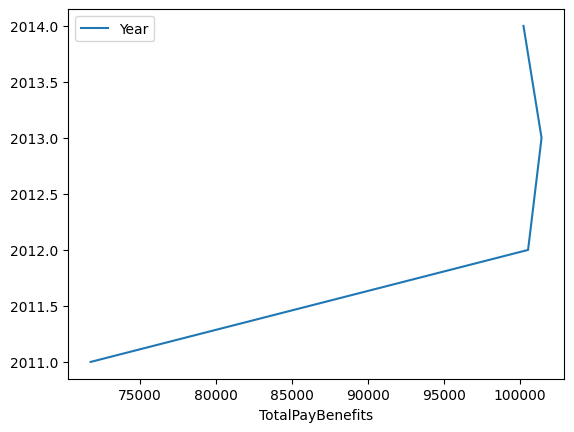

In [138]:
temp.plot(x ="TotalPayBenefits" , y = "Year",kind = "line")

#### 11)Are there any systematic increases in BasePay or Benefits for certain departments?

#### 12)Calculate the pay gap ratio between the highest-paid and lowest-paid employees.

In [139]:
highest_paid_emp = salaries[["EmployeeName","TotalPay"]].sort_values(by = "TotalPay", ascending = False).head(10).reset_index(drop = True)
highest_paid_emp.rename(columns = {"EmployeeName" : "highest_paid_emp_name", "TotalPay" : "highest_salaries"},inplace = True)

In [140]:
lowest_paid_emp= salaries[salaries["TotalPay"]>0][["EmployeeName","TotalPay"]].sort_values(by = "TotalPay").head(10).reset_index(drop = True)
lowest_paid_emp.rename(columns = {"EmployeeName" : "lowest_paid_emp_name", "TotalPay" : "lowest_salaries"},inplace = True)

In [141]:
temp = pd.concat([highest_paid_emp, lowest_paid_emp] , axis = 1)
temp["gap_ratio"] = round(temp["highest_salaries"]/temp["lowest_salaries"],1)
temp

,highest_paid_emp_name,highest_salaries,lowest_paid_emp_name,lowest_salaries,gap_ratio
0,NATHANIEL FORD,567595.43,JOE BROWN JR,0.30,1891984.8
1,GARY JIMENEZ,538909.28,Donald Clark,1.77,304468.5
2,David Shinn,471952.64,Sylvia R Jones,1.83,257897.6
3,Amy P Hart,390111.98,Cherise Wong,3.28,118936.6
4,Gary Altenberg,362844.66,SERENA HUGHES,4.17,87013.1
5,John Goldberg,350403.41,John Draper,4.75,73769.1
6,Samson Lai,347102.32,Nereida Vega,5.56,62428.5
7,Ellen G Moffatt,344187.46,ROCK CRAWFORD,5.80,59342.7
8,William J Coaker Jr.,339653.70,Renato C Gurion,6.00,56609.0
9,Gregory P Suhr,339282.07,Emily W Wakeman,7.60,44642.4


#### 13)Within the same job title, what is the pay variance (difference between max and min pay)?

#### 15)Which departments are most dependent on overtime to boost salaries?

#### 16)Is there a correlation between low BasePay and higher reliance on OvertimePay?

#### 17)Can we predict TotalPay using BasePay, OvertimePay, and OtherPay (via regression)?




#### 18)If overtime payments were reduced by 20%, how much would TotalPay decrease for the top 5 earning job titles?
there is no overtimepay for the highest paid jobtitles. So decrease in overtimepay won't affect these jobs

In [142]:
jobs = salaries.groupby("JobTitle")["TotalPay"].mean().sort_values(ascending = False).head()
jobs

JobTitle
GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY    399211.275000
CHIEF INVESTMENT OFFICER                          339653.700000
CHIEF, FIRE DEPARTMENT                            325971.683333
CHIEF OF POLICE                                   313885.882500
DEPUTY DIRECTOR OF INVESTMENTS                    307899.460000
Name: TotalPay, dtype: float64

In [143]:
salaries[salaries["JobTitle"].isin(jobs.index)]

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,0.00,567595.43,567595.43,2011,0.0,San Francisco,0
7,8,DAVID KUSHNER,DEPUTY DIRECTOR OF INVESTMENTS,256576.96,0.0,51322.50,0.00,307899.46,307899.46,2011,0.0,San Francisco,0
25,26,GREGORY SUHR,CHIEF OF POLICE,256470.41,0.0,11522.18,0.00,267992.59,267992.59,2011,0.0,San Francisco,0
83,84,EDWARD REISKIN,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,230827.12,0.0,0.00,0.00,230827.12,230827.12,2011,0.0,San Francisco,0
36160,36161,Gregory Suhr,CHIEF OF POLICE,302578.00,0.0,18974.11,69810.19,321552.11,391362.30,2012,0.0,San Francisco,0
36162,36163,Joanne Hayes-White,"CHIEF, FIRE DEPARTMENT",296943.01,0.0,17816.59,72047.88,314759.60,386807.48,2012,0.0,San Francisco,0
72925,72926,Gregory P Suhr,CHIEF OF POLICE,319275.01,0.0,20007.06,86533.21,339282.07,425815.28,2013,0.0,San Francisco,0
72926,72927,Joanne M Hayes-White,"CHIEF, FIRE DEPARTMENT",313686.01,0.0,23236.00,85431.39,336922.01,422353.40,2013,0.0,San Francisco,0
110533,110534,William J Coaker Jr.,CHIEF INVESTMENT OFFICER,257340.00,0.0,82313.70,96570.66,339653.70,436224.36,2014,0.0,San Francisco,PT
110534,110535,Gregory P Suhr,CHIEF OF POLICE,307450.04,0.0,19266.72,91302.46,326716.76,418019.22,2014,0.0,San Francisco,FT


#### 19)What percentage of employees would fall below $100,000 TotalPay if Benefits were excluded?

In [144]:
temp = salaries.copy()

In [145]:
temp["pay_excluding_benefits"]=temp["TotalPay"]-temp["Benefits"]

In [146]:
emp_count_below_100000 = temp[temp["pay_excluding_benefits"]< 100000].shape[0]

In [147]:
total_emp = salaries.shape[0]

In [148]:
print("percentage of employees would fall below $100,000 TotalPay if Benefits were excluded are : " ,round((emp_count_below_100000/total_emp)*100,2))

percentage of employees would fall below $100,000 TotalPay if Benefits were excluded are :  84.85


#### Q-4)Below questions are based on this data(Loan_default):-



In [149]:
loan = pd.read_csv('Loan_default.csv')
loan.sample(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
237314,HH0X102O1L,40,41398,138759,815,111,1,19.02,36,0.38,PhD,Part-time,Single,No,No,Business,No,0
142974,GQZ1ZL85UF,46,73312,212282,606,79,1,21.88,12,0.44,High School,Full-time,Divorced,Yes,No,Business,No,0
92623,99XVVZ6NIL,43,141458,113758,314,5,3,7.97,48,0.76,Bachelor's,Self-employed,Single,No,Yes,Home,No,0
205620,RVF9OJP4J8,68,35870,7916,638,49,3,3.41,48,0.82,PhD,Unemployed,Single,No,Yes,Home,Yes,0
82955,KQMUUET8IJ,36,97643,85046,471,71,2,18.64,12,0.18,PhD,Part-time,Married,Yes,No,Business,No,0


#### 1)How does Credit Score distribution differ between defaulted vs non-defaulted loans?

In [150]:
loan[loan["Default"]==1]["CreditScore"].mean()

np.float64(559.2861430546657)

In [151]:
loan[loan["Default"]==0]["CreditScore"].mean()

np.float64(576.2322702420091)

<Axes: ylabel='Frequency'>

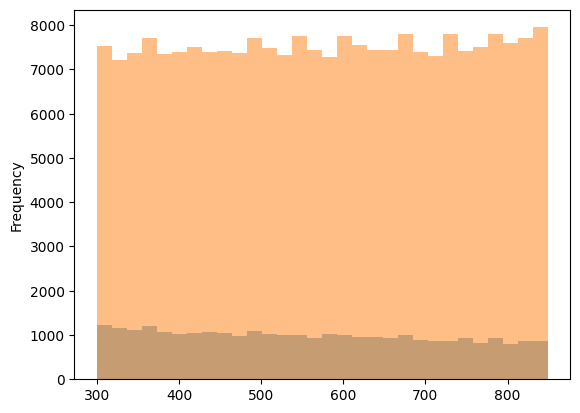

In [152]:
# method 1 to plot distribution
loan[loan["Default"]==1]["CreditScore"].plot(kind = "hist", bins = 30, alpha=0.5,label = "Defaulted")
loan[loan["Default"]==0]["CreditScore"].plot(kind = "hist", bins = 30,alpha=0.5, label = "Non-Defaulted")

<Axes: ylabel='Frequency'>

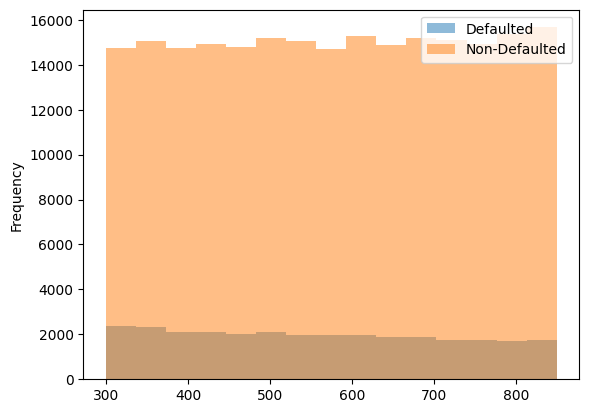

In [153]:
# method 2 to plot distribution
loan[loan["Default"]==1]["CreditScore"].plot.hist(legend=True, bins=15, alpha=0.5,label = "Defaulted")
loan[loan["Default"]==0]["CreditScore"].plot.hist(legend=True, bins=15, alpha=0.5,label = "Non-Defaulted")

#### 2)What is the probability of default for each Loan Purpose (Auto, Business, Home, Education, Other)?

In [154]:
temp = loan.groupby("LoanPurpose").agg(default_probability = ("Default" , "mean")).reset_index()
temp['default_probability'] = round((temp['default_probability']*100),2)
temp

,LoanPurpose,default_probability
0,Auto,11.88
1,Business,12.33
2,Education,11.84
3,Home,10.23
4,Other,11.79


#### 3)Is there a threshold of DTI Ratio (Debt-to-Income) above which defaults significantly increase?


In [155]:
temp = loan.copy()

In [156]:
bins = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]  
labels = ['0.1-0.2','0.2-0.3','0.3-0.4','0.4-0.5','0.5-0.6','0.6-0.7','0.7-0.8','0.8-0.9']

temp["DTIRatioIntervals"]=pd.cut(temp["DTIRatio"], bins=bins, labels=labels, include_lowest=True)


In [157]:
temp.sample(2)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,DTIRatioIntervals
100701,D12P33X449,35,100918,134386,492,15,2,3.99,12,0.67,Bachelor's,Self-employed,Married,No,Yes,Education,No,0,0.6-0.7
76974,XULCG5WD2E,46,111093,6674,837,26,3,6.92,48,0.21,Bachelor's,Unemployed,Married,Yes,Yes,Education,No,0,0.2-0.3


In [158]:
df = temp.groupby("DTIRatioIntervals")["Default"].mean().reset_index().rename(columns = {"Default" : "Default Rate"})


C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\265134327.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = temp.groupby("DTIRatioIntervals")["Default"].mean().reset_index().rename(columns = {"Default" : "Default Rate"})


In [159]:
df.set_index("DTIRatioIntervals", inplace = True)

<Axes: xlabel='DTIRatioIntervals'>

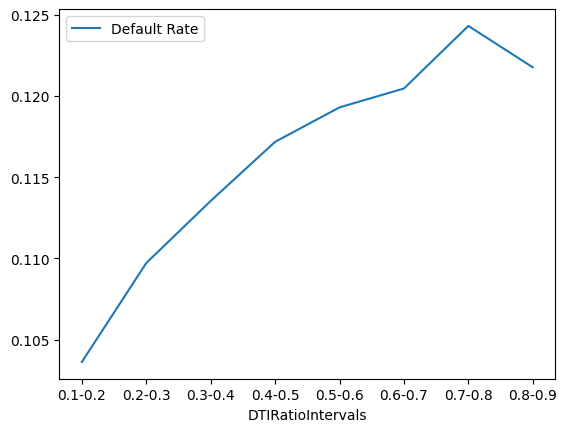

In [160]:
df.plot(kind = "line")

#### 4)Does Marital Status or Employment Type significantly impact default rates?


In [161]:
temp = loan.groupby("MaritalStatus").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,MaritalStatus,default_rates
0,Divorced,12.53
1,Married,10.40
2,Single,11.91


In [162]:
temp = loan.groupby("EmploymentType").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,EmploymentType,default_rates
0,Full-time,9.46
1,Part-time,11.97
2,Self-employed,11.46
3,Unemployed,13.55


In [163]:
temp = loan.groupby(["MaritalStatus","EmploymentType"]).agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp.sort_values(by = ["MaritalStatus","default_rates"])

,MaritalStatus,EmploymentType,default_rates
0,Divorced,Full-time,10.30
1,Divorced,Part-time,12.42
2,Divorced,Self-employed,12.64
3,Divorced,Unemployed,14.80
4,Married,Full-time,8.45
6,Married,Self-employed,10.16
5,Married,Part-time,11.03
7,Married,Unemployed,11.92
8,Single,Full-time,9.63
10,Single,Self-employed,11.61


#### 5)Which Education level borrowers are most likely to default, after adjusting for Income and Loan Amount?


##### 1. Without adjustment

 If you simply check defaults by Education, you might see something like:

 High School → 15% default

 Graduate → 10% default

 Postgraduate → 7% default

 At first glance, you’d think “High School borrowers are riskier”.

##### 2. The problem (confounding)

 But this difference may not be because of Education itself.

 High School borrowers may also have lower Income.

 They might also take bigger risky loans relative to their income.
 So the higher default might actually be due to Income and Loan Amount, not Education.

##### 3. Adjusting for Income & Loan Amount

 This means:
 We want to compare borrowers with similar Income and Loan Amounts, and then see if Education still makes a difference.

 For example:

 Among borrowers earning ₹50,000/month with loans of ₹5 lakh → Who defaults more?

 Among borrowers earning ₹1,00,000/month with loans of ₹10 lakh → Who defaults more?

 If High School borrowers still default more, even after comparing within the same income & loan size, then Education is truly a predictor of default.

In [164]:
# before adjusting for Income and Loan Amount the default rates are:-

temp = loan.groupby("Education").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,Education,default_rates
0,Bachelor's,12.10
1,High School,12.88
2,Master's,10.87
3,PhD,10.59


In [165]:
# creating income slab col

bins = [15000,25000,35000,45000,55000,65000,75000,85000,95000,105000,115000,125000,135000,145000,165000]
labels = ['15000-25000','25000-35000','35000-45000','45000-55000','55000-65000','65000-75000','75000-85000','85000-95000','95000-105000','105000-115000','115000-125000','125000-135000','135000-145000','145000-155000']
loan["IncomeSlab"] = pd.cut(loan["Income"], bins = bins, labels = labels, include_lowest=True)

In [166]:
loan["LoanAmount"].max()

np.int64(249999)

In [167]:
# creating loan amount slab col

bins = [5000,15000,25000,35000,45000,55000,65000,75000,85000,95000,105000,115000,125000,135000,145000,155000,165000,175000,185000,195000,205000,215000,225000,235000,250000]
labels = ['5000-15000','15000-25000','25000-35000','35000-45000','45000-55000','55000-65000','65000-75000','75000-85000','85000-95000','95000-105000','105000-115000','115000-125000','125000-135000','135000-145000','145000-155000','155000-165000','165000-175000','175000-185000','185000-195000','195000-205000','205000-215000','215000-225000','225000-235000','235000-250000']
loan["LoanAmountSlab"] = pd.cut(loan["LoanAmount"], bins = bins, labels = labels, include_lowest=True)

In [168]:
loan.sample(4)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,IncomeSlab,LoanAmountSlab
61438,XYCSI5D7PI,18,110711,39334,485,97,4,7.47,48,0.37,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0,105000-115000,35000-45000
201752,0OPT42D9K2,59,102572,248175,434,40,3,18.61,12,0.74,Bachelor's,Self-employed,Single,Yes,Yes,Business,Yes,0,95000-105000,235000-250000
189320,R7I0TNRO5S,43,119708,249281,659,43,4,24.29,12,0.13,Master's,Unemployed,Divorced,Yes,No,Home,No,0,115000-125000,235000-250000
159080,J3VNTU2UY6,36,37970,153875,379,61,1,9.86,60,0.67,PhD,Unemployed,Married,No,Yes,Education,Yes,0,35000-45000,145000-155000


In [169]:
# after adjusting for Income and Loan Amount

temp = loan.groupby( ["IncomeSlab", "LoanAmountSlab","Education"]).agg(default_rates = ("Default", "mean")).reset_index().sort_values(by = "default_rates",ascending = False)
temp["default_rates"]=round(temp["default_rates"]*100)

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\1167122651.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby( ["IncomeSlab", "LoanAmountSlab","Education"]).agg(default_rates = ("Default", "mean")).reset_index().sort_values(by = "default_rates",ascending = False)


In [170]:
temp.head(10)

,IncomeSlab,LoanAmountSlab,Education,default_rates
89,15000-25000,225000-235000,High School,48.0
93,15000-25000,235000-250000,High School,45.0
88,15000-25000,225000-235000,Bachelor's,45.0
85,15000-25000,215000-225000,High School,44.0
92,15000-25000,235000-250000,Bachelor's,43.0
94,15000-25000,235000-250000,Master's,43.0
84,15000-25000,215000-225000,Bachelor's,43.0
95,15000-25000,235000-250000,PhD,42.0
91,15000-25000,225000-235000,PhD,41.0
90,15000-25000,225000-235000,Master's,40.0


##### Borrowers with High School education and income 15000–25000, loan amount 225000–235000 have the highest default rate (48%).

##### Then come High School and Bachelor’s in similar income/loan ranges.

##### Higher education levels like PhD or Master’s generally show lower default rates (~40–43%).
##### Education level plays a role even after controlling for Income and Loan Amount. Less educated borrowers (like High School) default more frequently.

#### 6)Are younger vs older borrowers (using proxy = MonthsEmployed) at higher risk?


In [171]:
bins = [0,60,120]
labels=["younger","older"]
loan["MonthsEmployedAge"]=pd.cut(loan["MonthsEmployed"],bins = bins , labels = labels , include_lowest = True)

In [172]:
temp = loan.groupby("MonthsEmployedAge").agg(default_rate = ("Default","mean")).reset_index()
temp["default_rate"]=round(temp["default_rate"]*100,2)
temp

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\1745097575.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby("MonthsEmployedAge").agg(default_rate = ("Default","mean")).reset_index()


,MonthsEmployedAge,default_rate
0,younger,14.22
1,older,8.92


##### 7)For borrowers with similar Income levels, does LoanAmount size affect default likelihood?

In [173]:
temp = loan.groupby( ["IncomeSlab", "LoanAmountSlab"]).agg(default_rates = ("Default", "mean")).reset_index().sort_values(by = ["IncomeSlab","default_rates"],ascending = [True,False])
temp["default_rates"]=round(temp["default_rates"]*100)
temp

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\2442001720.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby( ["IncomeSlab", "LoanAmountSlab"]).agg(default_rates = ("Default", "mean")).reset_index().sort_values(by = ["IncomeSlab","default_rates"],ascending = [True,False])


,IncomeSlab,LoanAmountSlab,default_rates
22,15000-25000,225000-235000,44.0
23,15000-25000,235000-250000,43.0
21,15000-25000,215000-225000,40.0
19,15000-25000,195000-205000,38.0
20,15000-25000,205000-215000,37.0
...,...,...,...
322,145000-155000,105000-115000,8.0
314,145000-155000,25000-35000,8.0
316,145000-155000,45000-55000,8.0
323,145000-155000,115000-125000,7.0


#### 8)Is there a relationship between NumCreditLines and Loan Default Rate? (i.e., does having more credit lines reduce/increase risk?)

In [174]:
pd.set_option("display.max_columns",None)

In [175]:
temp = loan.groupby("NumCreditLines").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,NumCreditLines,default_rates
0,1,10.52
1,2,11.06
2,3,11.92
3,4,12.94


<Axes: xlabel='default_rates'>

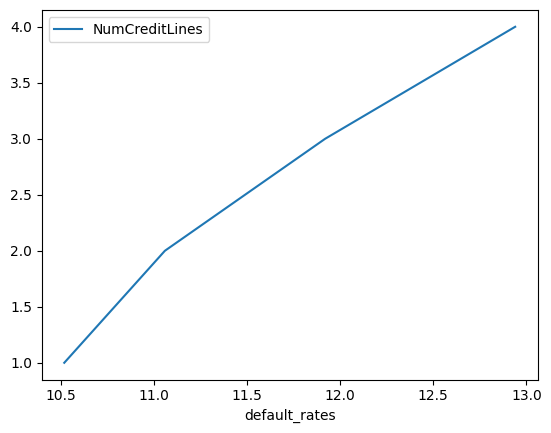

In [176]:
temp.plot(x = "default_rates", y = "NumCreditLines",kind="line")

#### 9)Does having a co-signer lower the probability of default?

In [177]:
temp = loan.groupby("HasCoSigner").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,HasCoSigner,default_rates
0,No,12.87
1,Yes,10.36


#### 10)Are borrowers with an existing mortgage more or less likely to default?

In [178]:
temp = loan.groupby("HasMortgage").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,HasMortgage,default_rates
0,No,12.35
1,Yes,10.88


#### 11)How does having dependents impact default risk, especially when Income is low?

In [179]:
temp = loan.groupby("HasDependents").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp

,HasDependents,default_rates
0,No,12.72
1,Yes,10.50


In [180]:
temp = loan.groupby(["HasDependents","IncomeSlab"]).agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp[temp["IncomeSlab"].isin(["15000-25000",'25000-35000','35000-45000','45000-55000'])]

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\2233650926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby(["HasDependents","IncomeSlab"]).agg(default_rates = ("Default", "mean")).reset_index()


,HasDependents,IncomeSlab,default_rates
0,No,15000-25000,25.94
1,No,25000-35000,17.71
2,No,35000-45000,14.45
3,No,45000-55000,12.82
14,Yes,15000-25000,22.19
15,Yes,25000-35000,15.28
16,Yes,35000-45000,12.08
17,Yes,45000-55000,10.72


<Axes: xlabel='IncomeSlab'>

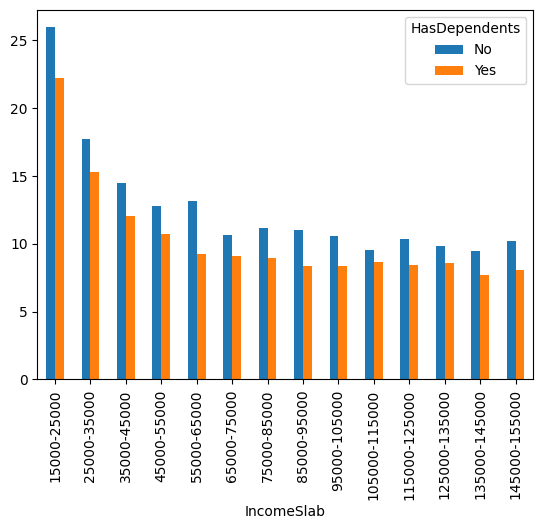

In [181]:
temp.pivot(index="IncomeSlab", columns="HasDependents", values="default_rates").plot(kind="bar")


#### 12)Which Loan Term (12, 24, 36, 48, 60 months) has the highest default rates?

In [182]:
bins = [0,12,24,36,48,60]
labels = ['0-12','12-24','24-36','36-48','48-60']
loan['LoanTermSlab'] = pd.cut(loan['LoanTerm'],bins = bins, labels = labels, include_lowest = True)

In [183]:
temp = loan.groupby("LoanTermSlab").agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp.sort_values(by = "default_rates")

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\1470352050.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby("LoanTermSlab").agg(default_rates = ("Default", "mean")).reset_index()


,LoanTermSlab,default_rates
3,36-48,11.57
2,24-36,11.57
1,12-24,11.61
0,0-12,11.62
4,48-60,11.70


#### 13)Does a higher Interest Rate directly correlate with higher default probability, or is it moderated by Credit Score?


In [184]:
bins = [2,4,8,12,16,20,25]
labels = ['2-4','4-8','8-12','12-16','16-20','20-25']
loan['InterestRateSlab'] = pd.cut(loan['InterestRate'],bins = bins, labels = labels, include_lowest = True)

In [185]:
bins = [0, 580, 670, 740, 800, loan["CreditScore"].max()]
labels = ["Poor (<580)", "Fair (580-669)", "Good (670-739)", "Very Good (740-799)", "Excellent (800+)"]
loan["CreditScoreSlab"] = pd.cut(loan["CreditScore"], bins=bins, labels=labels, include_lowest=True)
loan["CreditScoreSlab"].value_counts()


CreditScoreSlab
Poor (<580)            130708
Fair (580-669)          41877
Good (670-739)          31991
Very Good (740-799)     27771
Excellent (800+)        23000
Name: count, dtype: int64

In [186]:
temp = loan.groupby(["InterestRateSlab","CreditScoreSlab"]).agg(default_rates = ("Default", "mean")).reset_index()
temp["default_rates"]=round(temp["default_rates"]*100,2)
temp.sort_values(by = ["InterestRateSlab","default_rates"],ascending = False)

C:\Users\Hp\AppData\Local\Temp\ipykernel_13580\2889427756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = loan.groupby(["InterestRateSlab","CreditScoreSlab"]).agg(default_rates = ("Default", "mean")).reset_index()


,InterestRateSlab,CreditScoreSlab,default_rates
25,20-25,Poor (<580),19.07
26,20-25,Fair (580-669),17.42
27,20-25,Good (670-739),16.87
28,20-25,Very Good (740-799),16.13
29,20-25,Excellent (800+),14.82
20,16-20,Poor (<580),15.10
21,16-20,Fair (580-669),14.10
22,16-20,Good (670-739),12.93
24,16-20,Excellent (800+),12.85
23,16-20,Very Good (740-799),12.79


<Axes: xlabel='InterestRateSlab'>

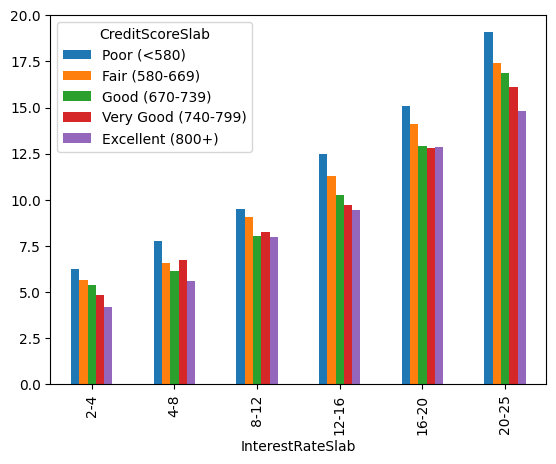

In [187]:
pivot = temp.pivot(index="InterestRateSlab", columns="CreditScoreSlab", values="default_rates")
pivot.plot(kind="bar")


#### 14)Segment customers into risk clusters (Low, Medium, High) using Income, LoanAmount, CreditScore, DTIratio, and analyze their default distribution.


In [188]:
# Income Slabs
loan["IncomeSlab2"] = pd.qcut(loan["Income"], 3, labels=["LowIncome","MidIncome","HighIncome"])

# Loan Amount Slabs
loan["LoanAmountSlab2"] = pd.qcut(loan["LoanAmount"], 3, labels=["SmallLoan","MidLoan","LargeLoan"])

# Credit Score Slabs (reverse logic: low score = risky)
loan["CreditScoreSlab2"] = pd.qcut(loan["CreditScore"], 3, labels=["LowScore","MidScore","HighScore"])

# DTI Ratio Slabs (higher ratio = risky)
loan["DTISlab"] = pd.qcut(loan["DTIRatio"], 3, labels=["LowDTI","MidDTI","HighDTI"])


In [189]:
def risk_level(row):
    # High Risk
    if (row["CreditScoreSlab"] == "LowScore") or \
       (row["DTISlab"] == "HighDTI") or \
       (row["IncomeSlab"] == "LowIncome" and row["LoanAmountSlab"] == "LargeLoan"):
        return "High"
    # Medium Risk
    elif (row["CreditScoreSlab"] == "MidScore") or \
         (row["DTISlab"] == "MidDTI") or \
         (row["IncomeSlab"] == "MidIncome" and row["LoanAmountSlab"] != "SmallLoan"):
        return "Medium"
    # Low Risk
    else:
        return "Low"

,RiskLevel,DefaultRate
0,High,0.122804
1,Low,0.108647
2,Medium,0.117214


In [193]:
loan["RiskLevel"] = loan.apply(risk_level, axis=1)
df = loan.groupby("RiskLevel")["Default"].mean().reset_index().rename(columns={"Default":"DefaultRate"})
df['DefaultRate'] = round(df['DefaultRate']*100,2)
df

,RiskLevel,DefaultRate
0,High,12.28
1,Low,10.86
2,Medium,11.72


#### 15)Can we identify a “safe borrower profile” (high probability of repayment) vs a “risky borrower profile”?

In [212]:
temp = loan.copy()

In [214]:
temp["credit"] = pd.qcut(temp["CreditScore"], 2, labels = ["LowCreditScore","HighCreditScore"])
temp["DTI"] = pd.qcut(temp["DTIRatio"], 2, labels = ["LowDTIRatio","HighDTIRatio"])

In [217]:
def borrower_profile(row):
    if (row["credit"]=="LowCreditScore") & (row["DTI"]=="LowDTIRatio"):
        return "risky borrower profile"
    else:
        return "safe borrower profile"

In [218]:
temp["borrower profile"] = temp.apply(borrower_profile, axis = 1)

In [230]:
df = temp.groupby("borrower profile").agg(default_rate = ("Default", "mean"))
df["default_rate"] = round(df["default_rate"]*100,2)
df

,default_rate
borrower profile,
risky borrower profile,12.04
safe borrower profile,11.47


#### 16)If interest rates were reduced by 10%, which borrower groups would show the largest reduction in default rates?


In [232]:
# temp = loan.copy()

In [231]:
# temp["ReducedInterestRate"] = temp["InterestRate"]-round(temp["InterestRate"]*0.1,2)
# temp[["InterestRate","ReducedInterestRate"]]

#### 17)For high-income but low-credit-score borrowers, what’s the impact of co-signer presence on default reduction?


In [233]:
temp = loan[(loan["IncomeSlab2"]=="HighIncome") & (loan["CreditScoreSlab"]=="Poor (<580)")].groupby("HasCoSigner").agg(default_rate = ("Default", "mean"))
temp["default_rate"] = round(temp["default_rate"]*100,2)
temp

,default_rate
HasCoSigner,
No,11.42
Yes,8.60
